<a href="https://colab.research.google.com/github/gd-Sahat/ClockBiasPINN/blob/main/tsf_mamba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
!pip install --quiet torch

In [38]:
!apt-get update -qq && apt-get install -qq libomp-dev

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [39]:
!pip install mamba-ssm --no-build-isolation

In [40]:
!pip install optuna

In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
import os
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from mamba_ssm import Mamba
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from numpy.lib.stride_tricks import sliding_window_view

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [44]:
DATA_PATH = '/content/drive/MyDrive/CLOCKBIASPINN/clkbias_diff.gz'

In [45]:
df = pd.read_csv(DATA_PATH, compression='gzip')

In [46]:
# If timestamp is not datetime, convert it
if not np.issubdtype(df['timestamp'].dtype, np.datetime64):
    df['timestamp'] = pd.to_datetime(df['timestamp'])
# Create time_ns feature directly from datetime (nanoseconds since epoch)
df['time_ns'] = df['timestamp'].astype(np.int64)
df['hours_since_start'] = (df['timestamp'] - df['timestamp'].min()).dt.total_seconds() / 3600 #raw ns cause scaling issue in data

# Encode satellite ID globally using factorize
df['id_enc'] = pd.factorize(df['id'])[0]


In [47]:
# Prepare raw features
raw_features = df[['id_enc','bias_interp_ns','bias_diff_ns','hours_since_start']].values

# Prepare and standardize targets
targets = df['bias_diff_ns'].values.astype(np.float32).reshape(-1, 1)

In [48]:
'''# --- 3. Scale and Split ---
N = len(raw_features)
train_end = int(N * 0.8)
val_end = int(N * 0.9)

scaler_X = StandardScaler()
scaler_y = StandardScaler()
scaler_X.fit(raw_features[:train_end])
scaler_y.fit(targets[:train_end].reshape(-1, 1))

features_scaled = scaler_X.transform(raw_features)
targets_scaled = scaler_y.transform(targets.reshape(-1, 1)).ravel()

features_train = features_scaled[:train_end]
targets_train  = targets_scaled[:train_end]
features_val   = features_scaled[train_end:val_end]
targets_val    = targets_scaled[train_end:val_end]
features_test  = features_scaled[val_end:]
targets_test   = targets_scaled[val_end:]'''

'# --- 3. Scale and Split ---\nN = len(raw_features)\ntrain_end = int(N * 0.8)\nval_end = int(N * 0.9)\n\nscaler_X = StandardScaler()\nscaler_y = StandardScaler()\nscaler_X.fit(raw_features[:train_end])\nscaler_y.fit(targets[:train_end].reshape(-1, 1))\n\nfeatures_scaled = scaler_X.transform(raw_features)\ntargets_scaled = scaler_y.transform(targets.reshape(-1, 1)).ravel()\n\nfeatures_train = features_scaled[:train_end]\ntargets_train  = targets_scaled[:train_end]\nfeatures_val   = features_scaled[train_end:val_end]\ntargets_val    = targets_scaled[train_end:val_end]\nfeatures_test  = features_scaled[val_end:]\ntargets_test   = targets_scaled[val_end:]'

In [49]:
# --- 5. Lazy Sliding Window Dataset ---
WINDOW_SIZE = 32
BATCH_SIZE = 2048

class LazyWindowDataset(Dataset):
    def __init__(self, features, targets, window_size):
        self.features = features
        self.targets = targets
        self.window_size = window_size

    def __len__(self):
        return len(self.features) - self.window_size

    def __getitem__(self, idx):
        X = self.features[idx:idx+self.window_size]
        y = self.targets[idx+self.window_size]
        return torch.from_numpy(X).float(), torch.tensor(y).float()

In [50]:
import numpy as np
import torch
from torch.utils.data import DataLoader

# --- Parameters ---
WINDOW_SIZE = 64
BATCH_SIZE  = 2048    # you can lower this if you still OOM
DEBUG_MODE  = True
DEBUG_SIZE  = 100000   # for quick tests

# 0) Optionally truncate for debug
if DEBUG_MODE:
    feats = raw_features[:DEBUG_SIZE]
    targs = targets[:DEBUG_SIZE]
else:
    feats = raw_features
    targs = targets

# 1) Sequential split on raw data
N = len(feats)
train_end = int(N * 0.8)
val_end   = int(N * 0.9)

# 2) Fit scalers on train only, transform each split
from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler().fit(feats[:train_end])
scaler_y = StandardScaler().fit(targs[:train_end].reshape(-1,1))

feats_train = scaler_X.transform(feats[:train_end])
targs_train = scaler_y.transform(targs[:train_end].reshape(-1,1)).ravel()

feats_val   = scaler_X.transform(feats[train_end:val_end])
targs_val   = scaler_y.transform(targs[train_end:val_end].reshape(-1,1)).ravel()

feats_test  = scaler_X.transform(feats[val_end:])
targs_test  = scaler_y.transform(targs[val_end:].reshape(-1,1)).ravel()

# 3) Use LazyWindowDataset on each split
train_ds = LazyWindowDataset(feats_train, targs_train, WINDOW_SIZE)
val_ds   = LazyWindowDataset(feats_val,   targs_val,   WINDOW_SIZE)
test_ds  = LazyWindowDataset(feats_test,  targs_test,  WINDOW_SIZE)

# 4) Build loaders (reduce batch size if necessary)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)


In [51]:
# right after you instantiate val_loader
xb, yb = next(iter(val_loader))
print(yb[:5])   # do these look ∼0 (mean) with std≈1?  Or thousands of ns?


tensor([-0.1475, -0.1411, -0.1487, -0.1471, -0.1479])


In [52]:
# grab one batch from each loader
xb_tr, yb_tr = next(iter(train_loader))
xb_val, yb_val = next(iter(val_loader))
xb_te, yb_te = next(iter(test_loader))

# print out a few values + overall mean/std
for name, yb in [("TRAIN", yb_tr), ("VAL", yb_val), ("TEST", yb_te)]:
    print(f"\n{name} y[:5]:", yb[:5].cpu().numpy())
    print(f"{name} mean: {yb.mean().item():.4f}, std: {yb.std().item():.4f}")



TRAIN y[:5]: [-0.41948712  0.39624375 -1.0402548  -0.69287467 -0.13137299]
TRAIN mean: 0.0180, std: 1.0189

VAL y[:5]: [-0.14752102 -0.14114556 -0.14867821 -0.1471327  -0.14788963]
VAL mean: -0.8015, std: 0.4931

TEST y[:5]: [-0.60803086 -0.6089125  -0.6031549  -0.60350335 -0.60492814]
TEST mean: -0.5830, std: 0.1678


In [53]:
print("Num training windows:", len(train_ds))
print("Batches per train epoch:", len(train_loader))
print("Num val windows:", len(val_ds))
print("Batches per val epoch:", len(val_loader))
print("Num test windows:", len(test_ds))
print("Batches per test epoch:", len(test_loader))

Num training windows: 79936
Batches per train epoch: 40
Num val windows: 9936
Batches per val epoch: 5
Num test windows: 9936
Batches per test epoch: 5


## **With Optimization**

In [54]:
'''import torch.optim as optim
import optuna

class EnhancedMambaModel(nn.Module):
    def __init__(self, input_dim, d_model=64, n_layers=3, dropout=0.05):
        super().__init__()
        self.fc_in = nn.Linear(input_dim, d_model)
        self.dropout = nn.Dropout(dropout)
        self.mamba_layers = nn.ModuleList([
            Mamba(d_model=d_model, d_state=16)
            for _ in range(n_layers)
        ])
        self.ln = nn.LayerNorm(d_model)
        self.fc_out = nn.Linear(d_model, 1)

    def forward(self, x):
        h = self.fc_in(x)
        h = self.dropout(h)
        for layer in self.mamba_layers:
            h = layer(h) + h
            h = self.dropout(h)
        h = self.ln(h)
        return self.fc_out(h.mean(dim=1))

# --- Dataset Definition ---
class LazyWindowDataset(torch.utils.data.Dataset):
    def __init__(self, features, targets, window_size):
        self.features = features
        self.targets = targets
        self.window_size = window_size
    def __len__(self):
        return len(self.features) - self.window_size
    def __getitem__(self, idx):
        X = self.features[idx:idx+self.window_size]
        y = self.targets[idx+self.window_size]
        return torch.from_numpy(X).float(), torch.tensor(y).float()

# --- Weight Initialization ---
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.LayerNorm):
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)

# --- Optuna Objective ---
def objective(trial):
    # Sample hyperparameters
    lr = trial.suggest_loguniform('lr', 1e-5, 1e-3)
    weight_decay = trial.suggest_loguniform('weight_decay', 1e-6, 1e-3)
    dropout = trial.suggest_uniform('dropout', 0.0, 0.3)
    d_model = trial.suggest_categorical('d_model', [32, 64, 128])
    n_layers = trial.suggest_int('n_layers', 1, 5)
    batch_size = trial.suggest_categorical('batch_size', [512, 1024, 2048])

    # Build model
    input_dim = raw_features.shape[1]
    model = EnhancedMambaModel(input_dim=input_dim, d_model=d_model, n_layers=n_layers, dropout=dropout).to(device)
    model.apply(init_weights)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    # Rebuild data loaders with new batch size
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, pin_memory=True)

    best_val_loss = float('inf')
    for epoch in range(1, 6):  # tune for 5 epochs
        # Training
        model.train()
        total_train = 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(Xb).squeeze()
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            total_train += loss.item() * Xb.size(0)
        # Validation
        model.eval()
        total_val = 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                preds = model(Xb).squeeze()
                loss = criterion(preds, yb)
                total_val += loss.item() * Xb.size(0)
        val_loss = total_val / len(val_loader.dataset)

        scheduler.step(val_loss)
        best_val_loss = min(best_val_loss, val_loss)

        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_val_loss

# --- Main Execution ---
if __name__ == '__main__':
    # Reproducibility
    SEED = 42
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Prepare raw_features, targets and initial datasets
    # raw_features, targets defined earlier
    # Build train_ds, val_ds once with a baseline split
    train_ds = LazyWindowDataset(feats_train, targs_train, WINDOW_SIZE)
    val_ds   = LazyWindowDataset(feats_val,   targs_val,   WINDOW_SIZE)

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=101)

    print('Best hyperparams:', study.best_trial.params)
    print('Best val MSE:', study.best_trial.value)
'''

"import torch.optim as optim\nimport optuna\n\nclass EnhancedMambaModel(nn.Module):\n    def __init__(self, input_dim, d_model=64, n_layers=3, dropout=0.05):\n        super().__init__()\n        self.fc_in = nn.Linear(input_dim, d_model)\n        self.dropout = nn.Dropout(dropout)\n        self.mamba_layers = nn.ModuleList([\n            Mamba(d_model=d_model, d_state=16)\n            for _ in range(n_layers)\n        ])\n        self.ln = nn.LayerNorm(d_model)\n        self.fc_out = nn.Linear(d_model, 1)\n\n    def forward(self, x):\n        h = self.fc_in(x)\n        h = self.dropout(h)\n        for layer in self.mamba_layers:\n            h = layer(h) + h\n            h = self.dropout(h)\n        h = self.ln(h)\n        return self.fc_out(h.mean(dim=1))\n\n# --- Dataset Definition ---\nclass LazyWindowDataset(torch.utils.data.Dataset):\n    def __init__(self, features, targets, window_size):\n        self.features = features\n        self.targets = targets\n        self.window_size 

In [55]:
'''import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
    plot_slice
)
# 1. How the best value evolved over trials
fig1 = plot_optimization_history(study)
fig1.show()

# 2. Which hyperparameters had the biggest impact
fig2 = plot_param_importances(study)
fig2.show()

# 3. Interactions between two or more parameters
fig3 = plot_parallel_coordinate(study, params=['lr', 'weight_decay', 'dropout'])
fig3.show()

# 4. Slice plots to see performance vs. a single parameter
fig4 = plot_slice(study, params=['lr', 'd_model', 'weight_decay', 'dropout'])
fig4.show()
'''

"import optuna\nfrom optuna.visualization import (\n    plot_optimization_history,\n    plot_param_importances,\n    plot_parallel_coordinate,\n    plot_slice\n)\n# 1. How the best value evolved over trials\nfig1 = plot_optimization_history(study)\nfig1.show()\n\n# 2. Which hyperparameters had the biggest impact\nfig2 = plot_param_importances(study)\nfig2.show()\n\n# 3. Interactions between two or more parameters\nfig3 = plot_parallel_coordinate(study, params=['lr', 'weight_decay', 'dropout'])\nfig3.show()\n\n# 4. Slice plots to see performance vs. a single parameter\nfig4 = plot_slice(study, params=['lr', 'd_model', 'weight_decay', 'dropout'])\nfig4.show()\n"

In [63]:
import time
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim

# --- Enhanced Mamba Model with Dropout ---
class EnhancedMambaModel(nn.Module):
    def __init__(self, input_dim, d_model=128, n_layers=3, dropout=0.1):
        super().__init__()
        self.fc_in = nn.Linear(input_dim, d_model)
        self.dropout = nn.Dropout(dropout)
        self.mamba_layers = nn.ModuleList([
            Mamba(d_model=d_model, d_state=16)
            for _ in range(n_layers)
        ])
        self.ln = nn.LayerNorm(d_model)
        self.fc_out = nn.Linear(d_model, 1)

    def forward(self, x):
        h = self.fc_in(x)
        h = self.dropout(h)
        for layer in self.mamba_layers:
            h = layer(h) + h
            h = self.dropout(h)
        h = self.ln(h)
        return self.fc_out(h.mean(dim=1))

# --- Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = feats_train.shape[1]
model = EnhancedMambaModel(input_dim=input_dim, d_model=128, n_layers=3, dropout=0.1).to(device)

# Initialize weights (clean model before training)
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.LayerNorm):
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)
model.apply(init_weights)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5, weight_decay=3.85e-5)
# LR scheduler to reduce LR on plateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    verbose=True
)

# Early stopping parameters
epochs = 100
best_val = float("inf")
patience = 15
epochs_no_improve = 0

# --- Training and Validation Loop ---
train_losses = []
val_losses = []
for epoch in range(1, epochs + 1):
    # Training
    model.train()
    total_train = 0
    start = time.time()
    for Xb, yb in tqdm(train_loader, desc=f"Epoch {epoch} [Train]", unit="batch"):
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(Xb).squeeze()
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_train += loss.item() * Xb.size(0)
    train_loss = total_train / len(train_loader.dataset)
    train_losses.append(train_loss)
    print(f"Epoch {epoch}: Train Loss {train_loss:.5f} ({time.time() - start:.2f}s)")

    # Validation
    model.eval()
    total_val = 0
    with torch.no_grad():
        for Xb, yb in tqdm(val_loader, desc=f"Epoch {epoch} [Val]", unit="batch"):
            Xb, yb = Xb.to(device), yb.to(device)
            preds = model(Xb).squeeze()
            loss = criterion(preds, yb)
            total_val += loss.item() * Xb.size(0)
    val_loss = total_val / len(val_loader.dataset)
    val_losses.append(val_loss)
    print(f"Epoch {epoch}: Val   Loss {val_loss:.5f}")

    # Scheduler step
    scheduler.step(val_loss)

    # Early stopping check
    if val_loss < best_val - 1e-6:
        best_val = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"No improvement after {patience} epochs, stopping early.")
            break

# --- Test Evaluation ---
model.load_state_dict(torch.load("best_model.pt"))
model.eval()
test_loss = 0
with torch.no_grad():
    for Xb, yb in tqdm(test_loader, desc="Test Eval", unit="batch"):
        Xb, yb = Xb.to(device), yb.to(device)
        preds = model(Xb).squeeze()
        loss = criterion(preds, yb)
        test_loss += loss.item() * Xb.size(0)
    test_loss /= len(test_loader.dataset)
print(f"Test Loss: {test_loss:.5f}")

# --- Debug: confirm losses stored correctly ---
print(f"Stored {len(train_losses)} train losses and {len(val_losses)} val losses.")
# You can now inspect or plot train_losses and val_losses as needed.


Epoch 1 [Train]: 100%|██████████| 40/40 [00:09<00:00,  4.02batch/s]


Epoch 1: Train Loss 5.66168 (9.95s)


Epoch 1 [Val]: 100%|██████████| 5/5 [00:00<00:00, 10.66batch/s]


Epoch 1: Val   Loss 5.09638


Epoch 2 [Train]: 100%|██████████| 40/40 [00:09<00:00,  4.00batch/s]


...

Epoch 34: Train Loss 0.04407 (10.03s)


Epoch 34 [Val]: 100%|██████████| 5/5 [00:00<00:00,  7.78batch/s]


Epoch 34: Val   Loss 0.15029
No improvement after 15 epochs, stopping early.


Test Eval: 100%|██████████| 5/5 [00:00<00:00, 10.64batch/s]

Test Loss: 0.36363
Stored 34 train losses and 34 val losses.


In [64]:
train_losses

[5.661679911174423,
 4.365075209123598,
 3.1740183751997324,
 2.113960489069967,
 1.2459906107716985,
 0.6519848720086299,
 0.3405019056806572,
 0.2168497418860992,
 0.16804653014823664,
 0.14425622296032664,
 0.12924340789059433,
 0.11850230457832377,
 0.11026365880826838,
 0.1042501529435619,
 0.09816405844029853,
 0.09288886555129762,
 0.08744213600054658,
 0.08247282463994572,
 0.07714300212548006,
 0.07220424207940018,
 0.06834086821115523,
 0.06277778535317764,
 0.058647327339821,
 0.05518991120750184,
 0.053343042638823925,
 0.05145568973284134,
 0.049321316158752425,
 0.04778374886338571,
 0.047221374145453215,
 0.046131769927431815,
 0.045510214666207374,
 0.044530870719515295,
 0.044036013154004267,
 0.04406669413189205]

In [65]:
val_losses

[5.096382313880367,
 3.6615253247308654,
 2.4784873427400265,
 1.588063378744847,
 0.9996226434738356,
 0.6432701597371155,
 0.43645642335480156,
 0.3175550865282375,
 0.24846339811257503,
 0.20399419082727602,
 0.17182171498327822,
 0.14575975259912954,
 0.12411710480752966,
 0.10585090844335572,
 0.09169273205617391,
 0.08092535854633688,
 0.07178147770644386,
 0.06660782897338008,
 0.06593345364798671,
 0.06636573275890136,
 0.07306854326080009,
 0.08255380378877099,
 0.09145205082812748,
 0.0986349075888666,
 0.10483735375070341,
 0.11197487623603256,
 0.12075217761663232,
 0.1265566106795689,
 0.13211503774887506,
 0.13743361127645304,
 0.14232721999167627,
 0.1448500448666909,
 0.14722325805208725,
 0.15028861745736066]

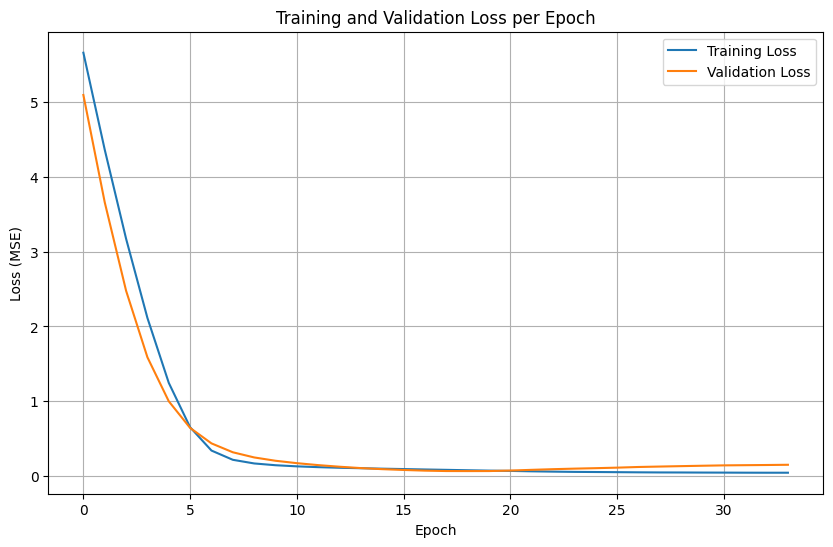

In [66]:
# prompt: plot train_losses and val_losses against epochs

import matplotlib.pyplot as plt

# Plotting the losses
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()


In [67]:
import numpy as np

# --- Load best model checkpoint ---
model.load_state_dict(torch.load("best_model.pt"))
model.to(device)
model.eval()

# --- Run inference on test_loader ---
preds_scaled = []
trues_scaled = []

with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        # forward
        out = model(Xb).squeeze().cpu().numpy()
        preds_scaled.append(out)
        trues_scaled.append(yb.numpy())

# concatenate batches
preds_scaled = np.concatenate(preds_scaled)   # shape (num_test_windows,)
trues_scaled = np.concatenate(trues_scaled)

# --- Inverse‐transform back to nanoseconds ---
# scaler_y is the StandardScaler you fit on y_train
preds_raw = scaler_y.inverse_transform(preds_scaled.reshape(-1,1)).ravel()
trues_raw = scaler_y.inverse_transform(trues_scaled.reshape(-1,1)).ravel()

# --- Compute and print RMSE ---
rmse = np.sqrt(np.mean((preds_raw - trues_raw)**2))
print(f"Test RMSE: {rmse:.2f} ns")

# Optionally, inspect the first few
for i in range(200):
    print(f"True: {trues_raw[i]:.2f} ns, Pred: {preds_raw[i]:.2f} ns")


Test RMSE: 1.09 ns
True: -3.39 ns, Pred: -3.97 ns
True: -3.39 ns, Pred: -3.97 ns
True: -3.38 ns, Pred: -3.97 ns
True: -3.38 ns, Pred: -3.97 ns
True: -3.38 ns, Pred: -3.96 ns
True: -3.37 ns, Pred: -3.96 ns
True: -3.37 ns, Pred: -3.96 ns
True: -3.36 ns, Pred: -3.96 ns
True: -3.36 ns, Pred: -3.96 ns
True: -3.36 ns, Pred: -3.96 ns
True: -3.37 ns, Pred: -3.96 ns
True: -3.36 ns, Pred: -3.96 ns
True: -3.37 ns, Pred: -3.95 ns
True: -3.35 ns, Pred: -3.95 ns
True: -3.36 ns, Pred: -3.95 ns
True: -3.36 ns, Pred: -3.95 ns
True: -3.36 ns, Pred: -3.95 ns
True: -3.36 ns, Pred: -3.95 ns
True: -3.35 ns, Pred: -3.95 ns
True: -3.35 ns, Pred: -3.94 ns
True: -3.34 ns, Pred: -3.94 ns
True: -3.34 ns, Pred: -3.94 ns
True: -3.34 ns, Pred: -3.94 ns
True: -3.33 ns, Pred: -3.94 ns
True: -3.33 ns, Pred: -3.94 ns
True: -3.33 ns, Pred: -3.94 ns
True: -3.33 ns, Pred: -3.93 ns
True: -3.32 ns, Pred: -3.93 ns
True: -3.31 ns, Pred: -3.93 ns
True: -3.33 ns, Pred: -3.93 ns
True: -3.31 ns, Pred: -3.93 ns
True: -3.31 ns, Pred

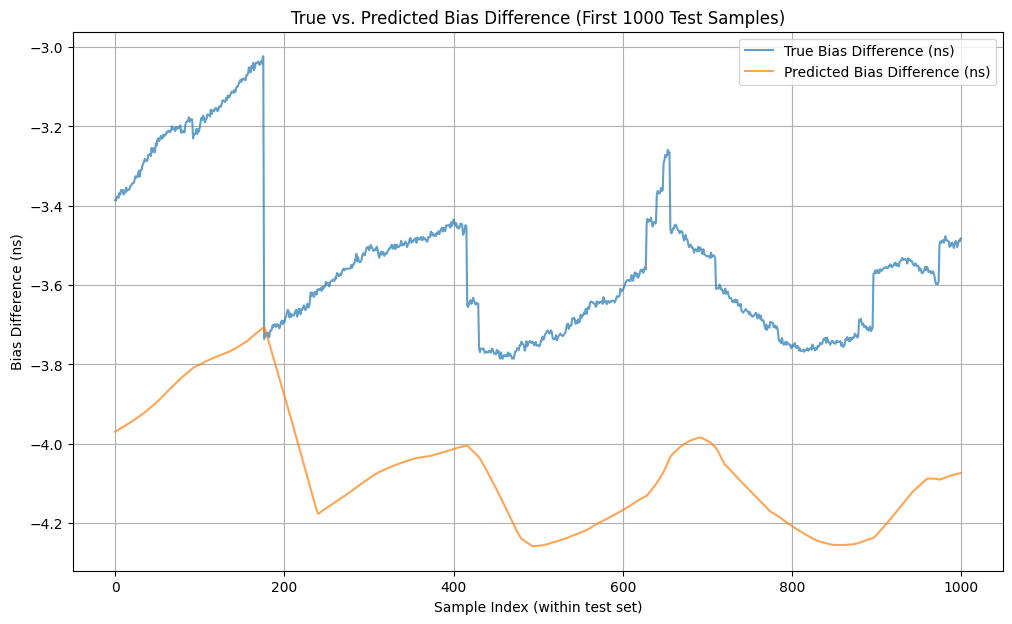

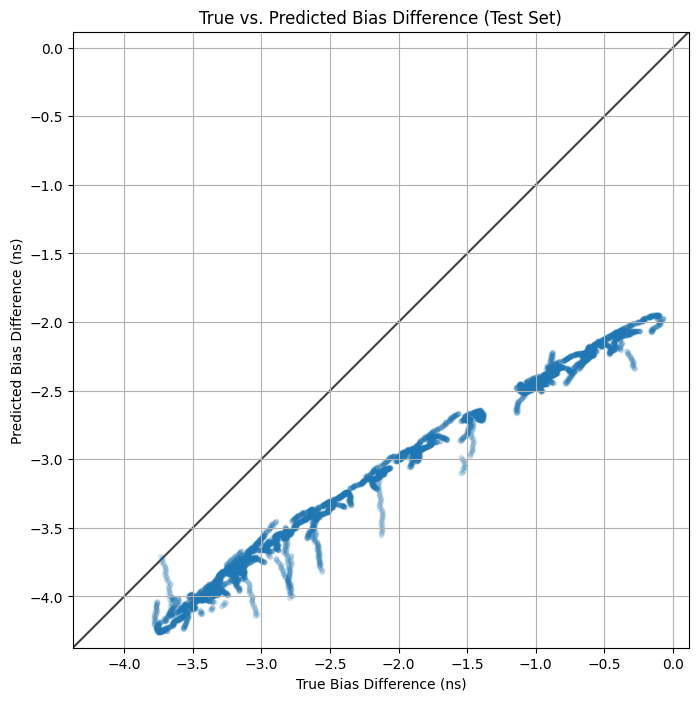

In [68]:
# prompt: plot true vs predicted

# --- Plot True vs Predicted ---
# Using a subset for clarity if the test set is very large
num_samples_to_plot = min(1000, len(trues_raw)) # Plot up to 1000 samples

plt.figure(figsize=(12, 7))
plt.plot(trues_raw[:num_samples_to_plot], label='True Bias Difference (ns)', alpha=0.7)
plt.plot(preds_raw[:num_samples_to_plot], label='Predicted Bias Difference (ns)', alpha=0.7)
plt.title(f'True vs. Predicted Bias Difference (First {num_samples_to_plot} Test Samples)')
plt.xlabel('Sample Index (within test set)')
plt.ylabel('Bias Difference (ns)')
plt.legend()
plt.grid(True)
plt.show()

# Optionally, a scatter plot to show correlation
plt.figure(figsize=(8, 8))
plt.scatter(trues_raw, preds_raw, alpha=0.1, s=10) # Use smaller markers and transparency for large datasets
plt.title('True vs. Predicted Bias Difference (Test Set)')
plt.xlabel('True Bias Difference (ns)')
plt.ylabel('Predicted Bias Difference (ns)')
plt.grid(True)
# Add a diagonal line representing perfect prediction
lims = [
    np.min([plt.xlim(), plt.ylim()]),  # min of both axes
    np.max([plt.xlim(), plt.ylim()]),  # max of both axes
]
plt.plot(lims, lims, 'k-', alpha=0.75, zorder=0)
plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect('equal', adjustable='box') # Ensure equal scaling
plt.show()
